In [5]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak
import time
import atlasopenmagic as atom
import vector as v

In [6]:
import math # for mathematical functions such as square root
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel # for the signal and background fits
import requests # for HTTP access
import aiohttp # HTTP client support

In [7]:
atom.set_release("2025e-13tev-beta")
skim = "GamGam"

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 788.36datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [56]:
files_list = atom.get_urls('data', skim, protocol='https', cache=True)
print(len(files_list))
print(files_list)
# period I appears to not exist, remove it
print(files_list[-3])
files_list.remove(files_list[-3])
print(len(files_list))

16
['simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodF.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodG.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodH.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodJ.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data16_periodA.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data16_periodB.GamGam.roo

In [ ]:
#TODO - delete
data15_periodD = files_list[0]
print(f"{data15_periodD = }")
treeD = uproot.open(data15_periodD+":analysis")
print(treeD.keys())
print(treeD['photon_isLooseID'])


data15_periodD = 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root'
['num_events', 'sum_of_weights', 'sum_of_weights_squared', 'category', 'sig_ph', 'n_sig_ph', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'xsec', 'filteff', 'kfac', 'channelNumber', 'eventNumber', 'runNumber', 'trigML', 'trigP', 'trigDT', 'trigT', 'trigE', 'trigDM', 'trigDE', 'trigM', 'trigMET', 'ScaleFactor_BTAG', 'ScaleFactor_JVT', 'jet_n', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_btag_quantile', 'jet_jvt', 'largeRJet_n', 'largeRJet_pt', 'largeRJet_eta', 'largeRJet_phi', 'largeRJet_e', 'largeRJet_m', 'largeRJet_D2', 'jet_pt_jer1', 'jet_pt_jer2', 'ScaleFactor_ELE', 'ScaleFactor_MUON', 'ScaleFactor_LepTRIGGER', 'ScaleFactor_MuTRIGGER', 'ScaleFactor_ElTRIGGER', 'lep_n', 'lep_type', 'lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_charge', 'lep_ptvarcone30', 'lep_topoetcone20', 'lep_z0', '

In [21]:
# examine tree for first data set
for dataD in treeD.iterate(variables,library='ak'):
    print(dataD['photon_isTightID'])
    print(dataD['photon_isTightID'][:,0])

[[True, True], [False, True], [False, ...], ..., [False, True], [False, False]]
[True, False, False, False, False, False, ..., False, True, True, False, False]


In [15]:
# make string list of relevant vars for analysis
variables = ["photon_pt","photon_eta","photon_phi","photon_e",
                            "photon_isTightID","photon_ptcone20"]

# Cuts
1) Identification criteria - photons need to be identified as photons, not misidentified jets or something
2) pT cuts: >50GeV for gam1, >30GeV gam2
3) photons must have calorimeter isolation
4) exclude endcap-barrel transition region 1.37 < |η| < 1.52
5) pT relative to invariant mass threshold: $p_T/m_{\gamma\gamma} > 0.35$ - keeps photons symmetric and energetic relative to system. background events tend to be asymmetric

Mass calculation is the same as in the HZZ analysis (see comments there https://github.com/chrissellgrenbackup/intro-hep-project/blob/main/higgs_analysis/HZZ_analysis.ipynb)



In [30]:
# note that [:,0] corresponds to first photon for all events
# -> for photon_isTightID branch!
# [:,1] corresponds to second photon for all events
def cut_photon_id(photon_isTightID):
    return (photon_isTightID[:,0] == True) & (photon_isTightID[:,1] == True)

def cut_pt(photon_pt):
    g1ptpass = photon_pt[:,0] > 50
    g2ptpass = photon_pt[:,1] > 30
    return (g1ptpass & g2ptpass)

# Only the events where the invidivual photon calorimeter isolation is less than 5.5% are kept
# ptcone20 is the amount of energy within a cone around the photon (0.2 in eta-phi space)
# want to ensure most of the energy around the photon is only coming from the photon to discard jets
def cut_isolation_pt(photon_ptcone20,photon_pt):
    return (photon_ptcone20[:,0]/photon_pt[:,0] < 0.055) & (photon_ptcone20[:,1]/photon_pt[:,1] < 0.055)

# 1.37 < |η| < 1.52 region cut
def cut_transition(photon_eta):
    g1cut = (np.abs(photon_eta[:,0]) > 1.52) | (np.abs(photon_eta[:,0]) < 1.37)
    g2cut = (np.abs(photon_eta[:,1]) > 1.52) | (np.abs(photon_eta[:,1]) < 1.37)
    return (g1cut & g2cut)

# this function same as in HZZ
def calc_mass(pt,eta,phi,E):
    # first create a 4vec for each of the particles
    p4 = v.zip({"pt":pt,"eta":eta,"phi":phi,"e":E})
    p4_sum = p4[:,0] + p4[:,1]
    M = p4_sum.M
    return M

# discard events with diphoton mass = 0 
def cut_mass(M):
    return (M != 0)

# make pt/M cut
# pT relative to invariant mass threshold: $p_T/m_{\gamma\gamma} > 0.35$ 
# keeps photons symmetric and energetic relative to system
def cut_ptvsm(photon_pt,M):
    return (photon_pt[:,0]/M > 0.35) & (photon_pt[:,1]/M > 0.35)

Loop over one data file

In [35]:
print("Examining data file: "+str(data15_periodD))

data_sampleD = []
for data in treeD.iterate(variables,library='ak'):
    print("Num events before cuts: "+str(len(data)))
    data = data[cut_photon_id(data['photon_isTightID'])]
    print("Num events after ID cuts: "+str(len(data)))
    data = data[cut_pt(data['photon_pt'])]
    print("Num events after pT cuts: "+str(len(data)))
    data = data[cut_isolation_pt(data['photon_ptcone20'],data['photon_pt'])]
    print("Num events after calorimeter isolation cuts: "+str(len(data)))
    data = data[cut_transition(data['photon_eta'])]
    print("Num events after transition region cuts: "+str(len(data)))
    
    data['mass'] = calc_mass(data['photon_pt'],data['photon_eta'],data['photon_phi'],data['photon_e'])

    data = data[cut_mass(data['mass'])]
    print("Num events after null diphoton mass cuts: "+str(len(data)))
    data = data[cut_ptvsm(data['photon_pt'],data['mass'])]
    print("Num events after photon pT vs mass cuts: "+str(len(data)))

    data_sampleD.append(data['mass'])

data15_periodD = ak.concatenate(data_sampleD)

Examining data file: [{photon_pt: [59.6, 36.7], photon_eta: [-0.056, ...], ...}, {...}, ..., {...}]
Num events before cuts: 63195
Num events after ID cuts: 8392
Num events after pT cuts: 2312
Num events after calorimeter isolation cuts: 1240
Num events after transition region cuts: 1231
Num events after null diphoton mass cuts: 1231
Num events after photon pT vs mass cuts: 787


## Plot data from first file


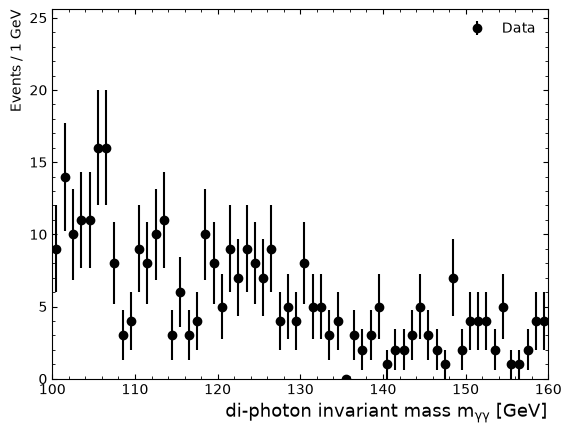

In [36]:
# x-axis range of the plot
xmin = 100 #GeV
xmax = 160 #GeV

# Histogram bin setup
step_size = 1 #GeV
bin_edges = np.arange(start=xmin, # The interval includes this value
                    stop=xmax+step_size, # The interval doesn't include this value
                    step=step_size ) # Spacing between values
bin_centres = np.arange(start=xmin+step_size/2, # The interval includes this value
                        stop=xmax+step_size/2, # The interval doesn't include this value
                        step=step_size ) # Spacing between values

# Creating histogram from data
data_x,_ = np.histogram(ak.to_numpy(data15_periodD),
                        bins=bin_edges ) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data


# *************
# Main plot
# *************
main_axes = plt.gca() # get current axes

# plot the data points
main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                    fmt='ko', # 'k' means black and 'o' is for circles
                    label='Data')

# set the x-limit of the main axes
main_axes.set_xlim( left=xmin, right=xmax )

# separation of x axis minor ticks
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
main_axes.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

# x-axis label
main_axes.set_xlabel(r'di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )

# write y-axis label for main axes
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')

# set y-axis limits for main axes
main_axes.set_ylim( bottom=0, top=np.amax(data_x)*1.6 )

# add minor ticks on y-axis for main axes
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# draw the legend
main_axes.legend( frameon=False ); # no box around the legend

## Loop over all files

In [57]:
data_files = []

for f in files_list:
    starttime = time.time()
    print('-'*80)
    print(r'\n\t Processing file: ' + str(f))
    tree = uproot.open(f+':analysis')
    print("File opened with uproot.")

    #loop through tree
    for data in tree.iterate(variables,library='ak'):
        print("Num events before cuts: "+str(len(data)))
        data = data[cut_photon_id(data['photon_isTightID'])]
        print("Num events after ID cuts: "+str(len(data)))
        data = data[cut_pt(data['photon_pt'])]
        print("Num events after pT cuts: "+str(len(data)))
        data = data[cut_isolation_pt(data['photon_ptcone20'],data['photon_pt'])]
        print("Num events after calorimeter isolation cuts: "+str(len(data)))
        data = data[cut_transition(data['photon_eta'])]
        print("Num events after transition region cuts: "+str(len(data)))
        
        data['mass'] = calc_mass(data['photon_pt'],data['photon_eta'],data['photon_phi'],data['photon_e'])

        data = data[cut_mass(data['mass'])]
        print("Num events after null diphoton mass cuts: "+str(len(data)))
        data = data[cut_ptvsm(data['photon_pt'],data['mass'])]
        print("Num events after photon pT vs mass cuts: "+str(len(data)))

        data_files.append(data['mass'])

print("Done processing data...")
alldata = ak.concatenate(data_files)
    

--------------------------------------------------------------------------------
\n\t Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root
File opened with uproot.
Num events before cuts: 63195
Num events after ID cuts: 8392
Num events after pT cuts: 2312
Num events after calorimeter isolation cuts: 1240
Num events after transition region cuts: 1231
Num events after null diphoton mass cuts: 1231
Num events after photon pT vs mass cuts: 787
--------------------------------------------------------------------------------
\n\t Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root
File opened with uproot.
Num events before cuts: 529228
Num events after ID cuts: 73737
Num events after pT cuts: 20042
Num events after calorimeter isolation cuts: 10760
Num events after transition region cuts: 10667
Num events after null dipho

Text(150, 32, '$\\sqrt{s}$ = 13 TeV, $\\int L dt =$ 36.6fb$^{-1}$')

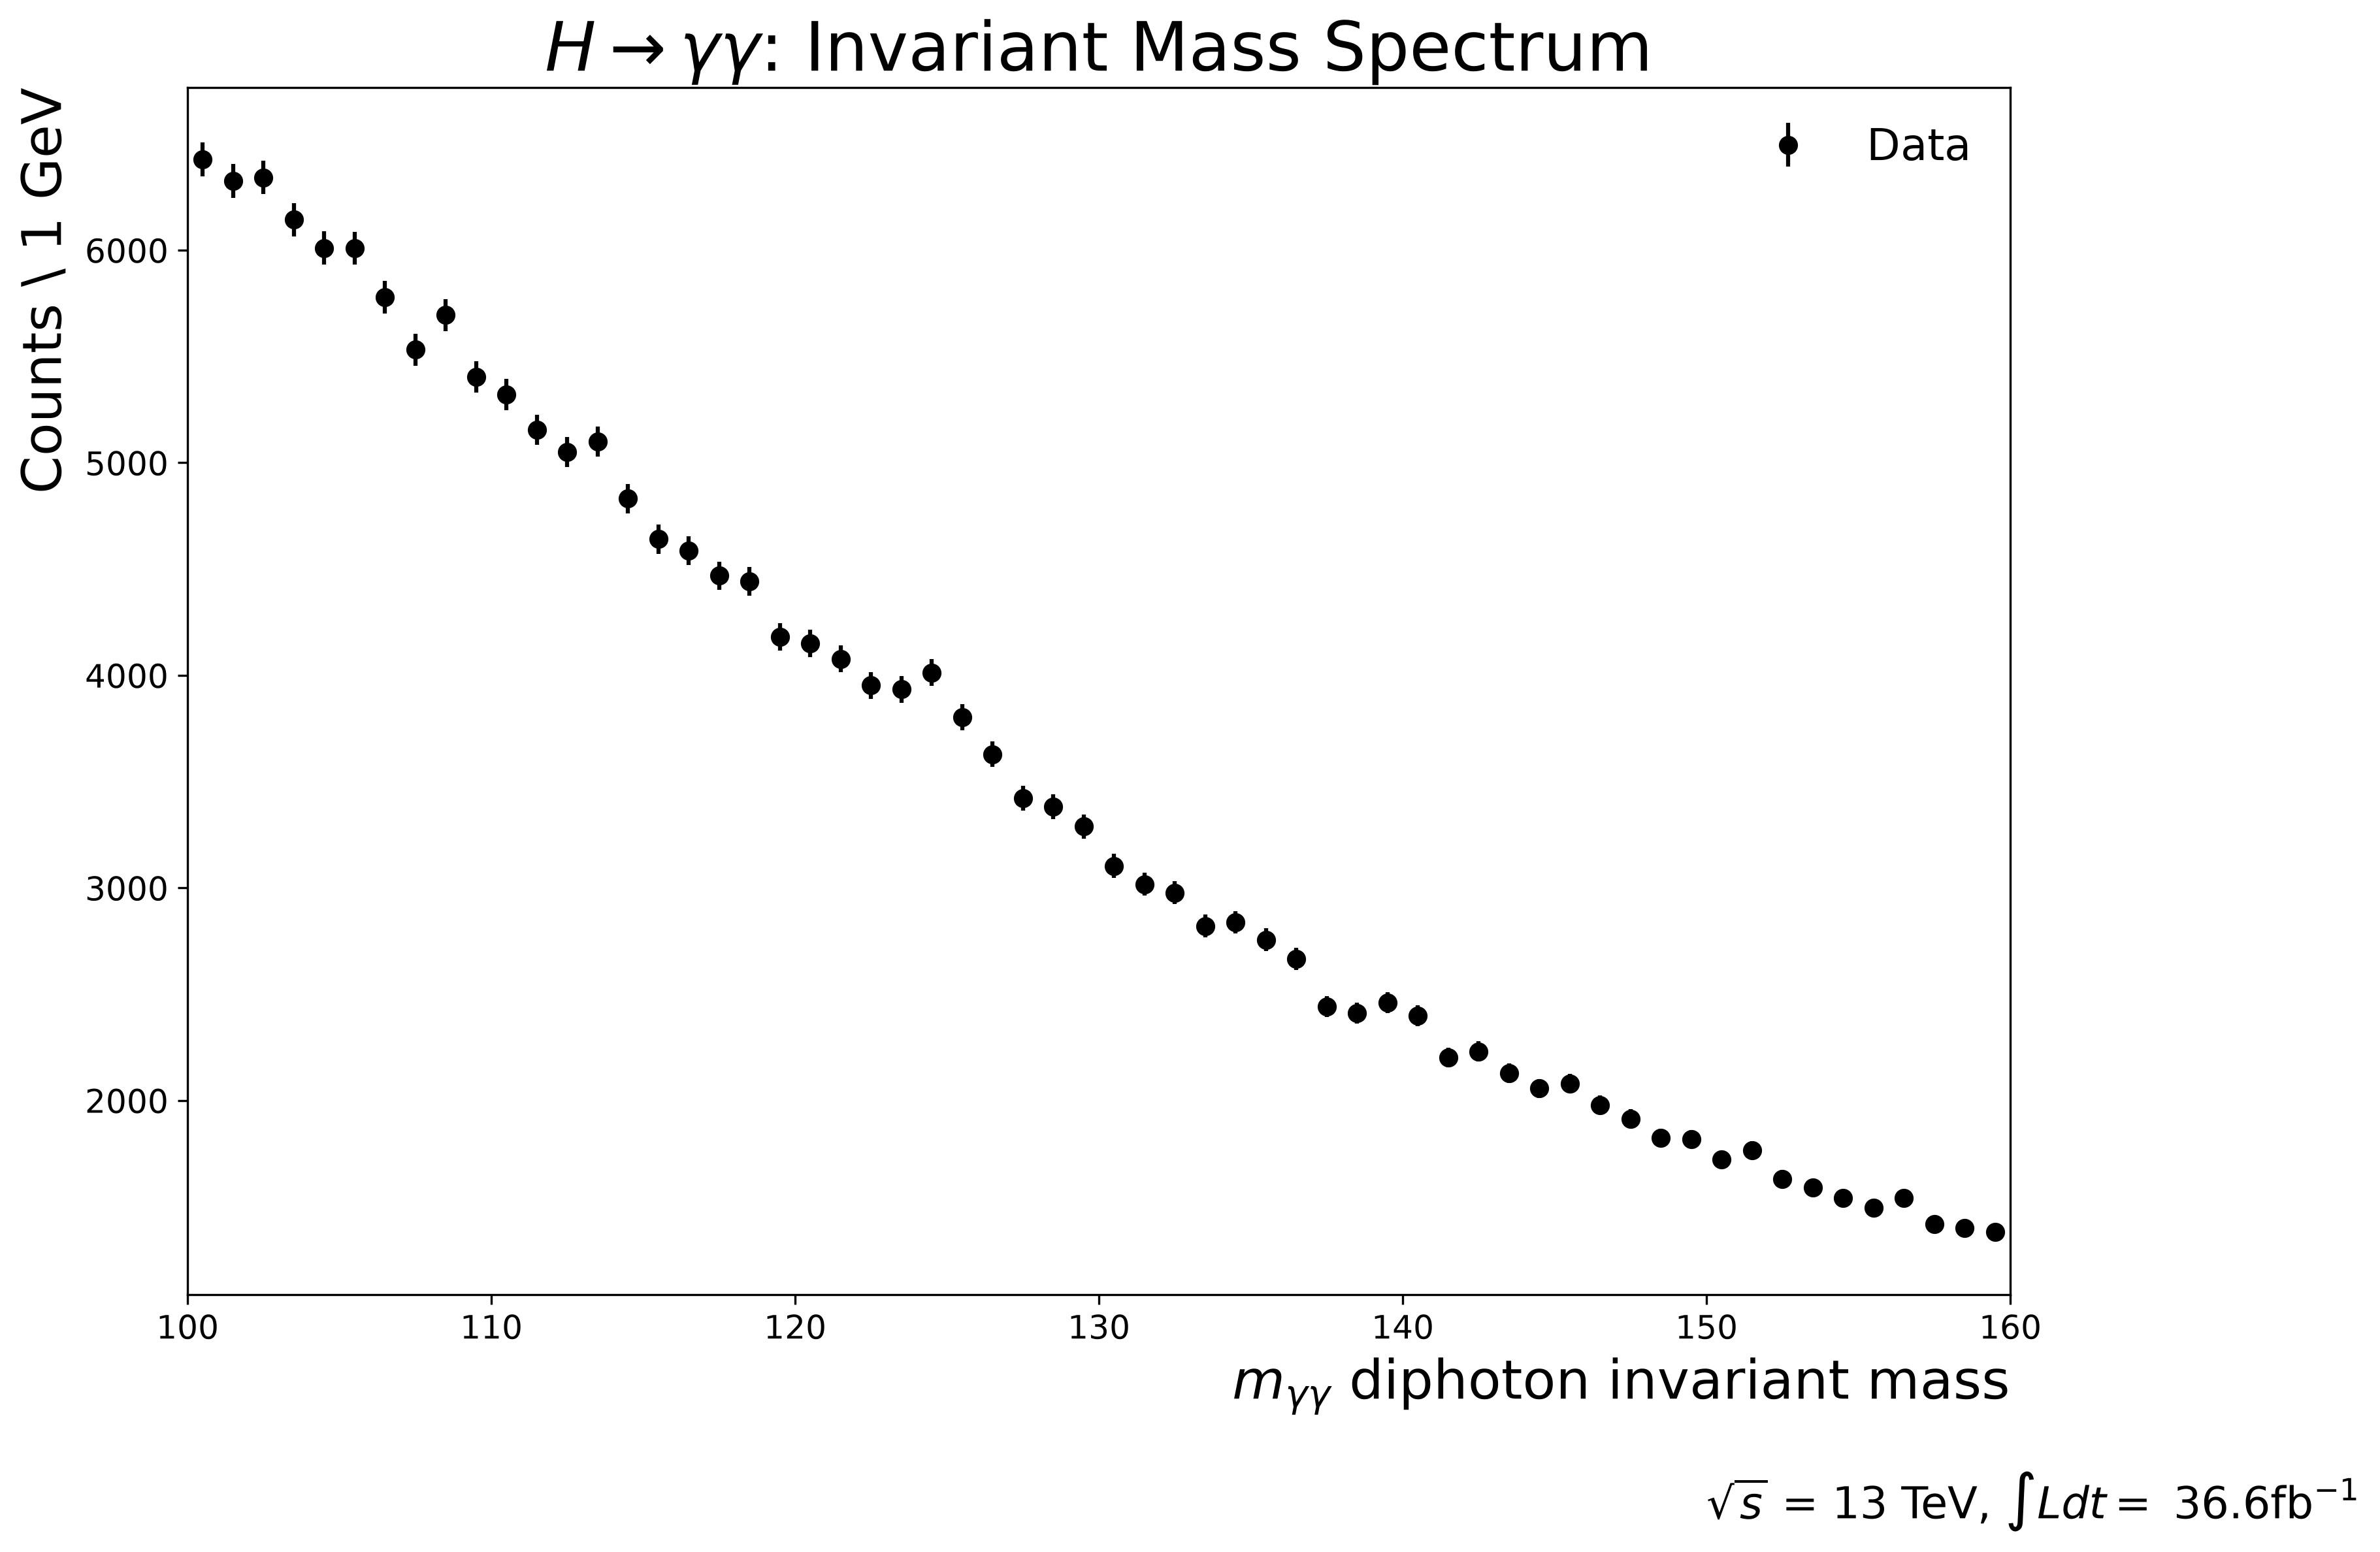

In [62]:
xmin = 100 # GeV
xmax = 160
step_size = 1
stepsize = 1
binlist = np.arange(xmin,xmax+step_size,step_size)
bincenters = np.arange(xmin+stepsize/2,xmax+stepsize/2,step_size)

data_y, _ = np.histogram(ak.to_numpy(alldata),bins=binlist)
data_y_err = np.sqrt(data_y)

fig, ax = plt.subplots(figsize=(12,8),dpi=300)
ax.errorbar(bincenters,data_y,yerr=data_y_err,fmt='o',color='black',label='Data')
ax.set_xlabel(r'$m_{\gamma\gamma}$ diphoton invariant mass',x=1,horizontalalignment ='right',fontsize=20)
ax.set_ylabel(f'Counts \ {step_size} GeV',y=1,horizontalalignment ='right',fontsize=20)
ax.set_title(r"$H \rightarrow \gamma\gamma$: Invariant Mass Spectrum",fontsize=25)
ax.legend(frameon=False,fontsize='16')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(xmin,xmax)
plt.text(150,32,r'$\sqrt{s}$ = 13 TeV, $\int L dt =$ 36.6fb$^{-1}$',fontsize=16)

In [91]:
### do the polynomial fit
poly_fit = PolynomialModel(4) #4th order poly
gauss_fit = GaussianModel()
# set initial guesses for poly
# c0 + c1 * x + c2 * x**2 + ...
x = bincenters
pars = poly_fit.guess(data_y,x=x,
                      c0 = data_y.max(), c1=0,c2=0,c3=0) #use zeroth order taylor poly as guess input
pars = pars + gauss_fit.guess(data_y,x=bincenters,amplitude=100,
                              center = 125, sigma = 2) # feed educated guess to gaussian

model = poly_fit + gauss_fit
# note that smaller errorbars should have larger weight on fit
fit = model.fit(data_y,pars,x=x,
                weights=1/data_y_err) # weights in lmfit are interepreted as 1/sigma

params_dict = fit.params.valuesdict()
c0 = params_dict['c0']
c1 = params_dict['c1']
c2 = params_dict['c2']
c3 = params_dict['c3']
c4 = params_dict['c4']


bg_y = c0 + c1*x + c2*x**2 + c3*x**3 + c4*x**4
signal_y = data_y - bg_y


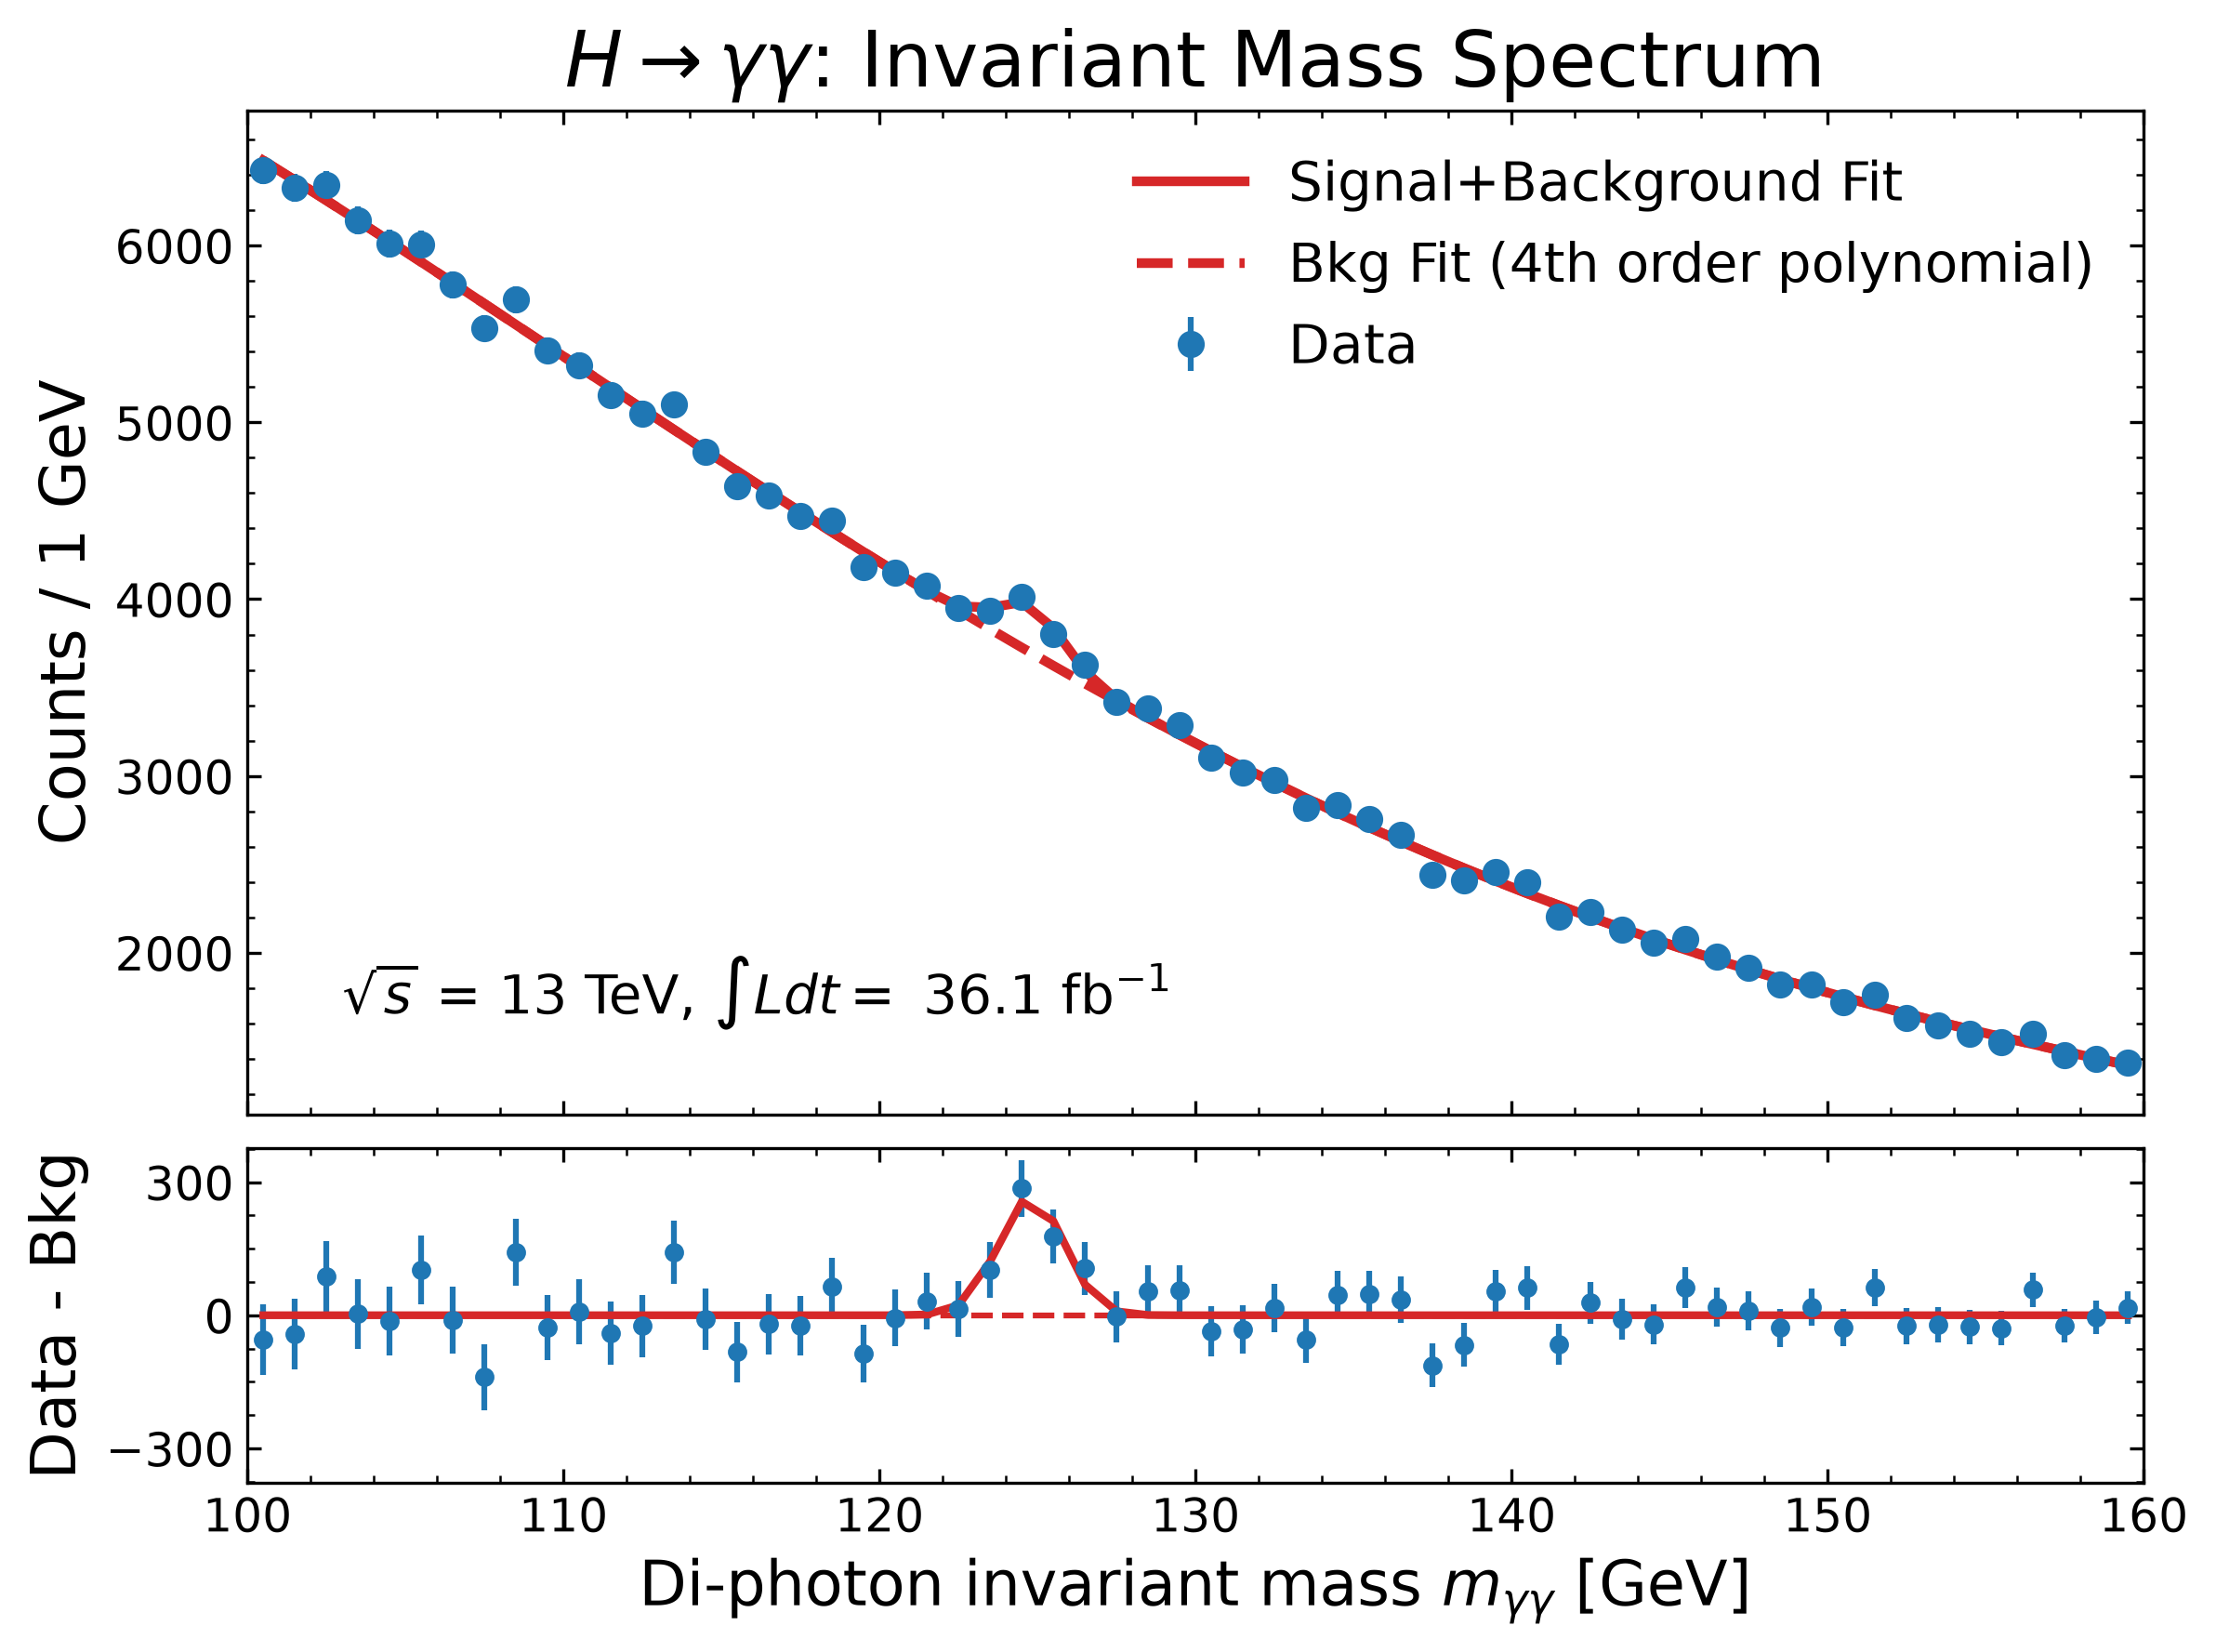

In [125]:
data_color = '#1f77b4'   
fit_color = '#d62728'  

fig = plt.figure(figsize=(8, 6), dpi=300)

# data + fit main plot
# using rect=[left, bottom, width, height]
ax = plt.axes([0.1, 0.32, 0.85, 0.60])

ax.errorbar(x, data_y, yerr=data_y_err, fmt='o', color=data_color, label='Data')
ax.plot(x, fit.best_fit, '-', color=fit_color, label="Signal+Background Fit", linewidth=2.5)
ax.plot(x, bg_y, '--', color=fit_color, label="Bkg Fit (4th order polynomial)", linewidth=2.5)

ax.set_ylabel(f'Counts / {step_size} GeV', fontsize=18)
ax.set_title(r"$H \rightarrow \gamma\gamma$: Invariant Mass Spectrum", fontsize=20)
ax.legend(frameon=False, fontsize='14', loc='upper right')

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# hide x-tick labels on the upper plot to avoid overlapping with the lower plot
plt.setp(ax.get_xticklabels(), visible=False)

plt.yticks(fontsize=12)
plt.xlim(xmin, xmax)
plt.text(0.05, 0.1, r'$\sqrt{s}$ = 13 TeV, $\int L dt =$ 36.1 fb$^{-1}$', 
         transform=ax.transAxes, fontsize=14)


# lower plot
sub_axes = plt.axes([0.1, 0.1, 0.85, 0.20], sharex=ax)

# Set the y axis to be symmetric about 0
sub_axes.yaxis.set_major_locator(MaxNLocator(nbins='auto', symmetric=True))

# plot data-bg
sub_axes.errorbar(x=x, y=signal_y, yerr=data_y_err, fmt='o', color=data_color, markersize=4, label='_nolegend_')
# Draw the fit to data
sub_axes.plot(bin_centres, fit.best_fit - bg_y, '-', color=fit_color, linewidth=2)
# bg only reference line
sub_axes.plot(x, bg_y - bg_y, '--', color=fit_color, linewidth=1.5)

sub_axes.set_xlim(left=xmin, right=xmax)
sub_axes.xaxis.set_minor_locator(AutoMinorLocator())
sub_axes.yaxis.set_minor_locator(AutoMinorLocator())

# Standardize tick label sizes for both axes
sub_axes.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)

ax.set_ylabel(f'Counts / {step_size} GeV', fontsize=16)
sub_axes.set_ylabel('Data - Bkg', fontsize=16)

sub_axes.set_xlabel(r'Di-photon invariant mass $m_{\gamma\gamma}$ [GeV]', fontsize=16)
plt.savefig("plots/Hgg_massspec.png")